# Predicting House Prices with Linear Models

This notebook develops an interpretable linear model for house price prediction.

Key requirements:
- Main models are linear (OLS, Ridge, Lasso, Elastic Net)
- Performance evaluated using MAPE on original price scale
- Cross-validation used for model development
- XGBoost included only as a benchmark

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

## 1. Data Loading

We load the dataset and inspect its basic structure before cleaning.

In [5]:
df_raw = pd.read_csv("data/house_dataset_2.csv")

print("Original shape:", df_raw.shape)
df_raw.head()

Original shape: (9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## 2. Data Cleaning

We clean the dataset to ensure valid modeling:

- Remove duplicate rows
- Remove rows with zero or invalid price (MAPE cannot handle zero)
- Replace `yr_renovated = 0` with missing values
- Drop `street` and `country` (high-cardinality / low value)
- Cap extreme bedroom outliers

In [6]:
df = df_raw.copy()

rows_before = len(df)

# Remove duplicates
duplicates = df.duplicated().sum()
df = df.drop_duplicates()

# Remove invalid prices
invalid_price = (df["price"] <= 0).sum()
df = df[df["price"] > 0]

# Fix renovation
df["yr_renovated"] = df["yr_renovated"].replace(0, np.nan)

# Drop problematic columns
df = df.drop(columns=["street", "country"], errors="ignore")

# Fix bedroom outlier
df["bedrooms"] = df["bedrooms"].clip(upper=10)

rows_after = len(df)

print("Rows before:", rows_before)
print("Duplicates removed:", duplicates)
print("Invalid price removed:", invalid_price)
print("Rows after:", rows_after)

Rows before: 9200
Duplicates removed: 4598
Invalid price removed: 49
Rows after: 4553


In [7]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
Index: 4553 entries, 0 to 8938
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4553 non-null   object 
 1   price          4553 non-null   float64
 2   bedrooms       4553 non-null   float64
 3   bathrooms      4553 non-null   float64
 4   sqft_living    4553 non-null   int64  
 5   sqft_lot       4553 non-null   int64  
 6   floors         4553 non-null   float64
 7   waterfront     4553 non-null   int64  
 8   view           4553 non-null   int64  
 9   condition      4553 non-null   int64  
 10  sqft_above     4553 non-null   int64  
 11  sqft_basement  4553 non-null   int64  
 12  yr_built       4553 non-null   int64  
 13  yr_renovated   1846 non-null   float64
 14  city           4553 non-null   object 
 15  statezip       4553 non-null   object 
dtypes: float64(5), int64(8), object(3)
memory usage: 604.7+ KB


yr_renovated     2707
date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
sqft_above          0
sqft_basement       0
yr_built            0
city                0
statezip            0
dtype: int64

In [8]:
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(4553, 16)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005.0,Shoreline,WA 98133
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,NaN,Seattle,WA 98119
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,NaN,Kent,WA 98042
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,NaN,Bellevue,WA 98008
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992.0,Redmond,WA 98052


## 3. Exploratory Data Analysis

This section examines the main patterns in the dataset to guide feature engineering and model design.

The EDA focuses on:
- the distribution of house prices
- the relationship between property size and price
- variation across locations
- numerical associations with the target

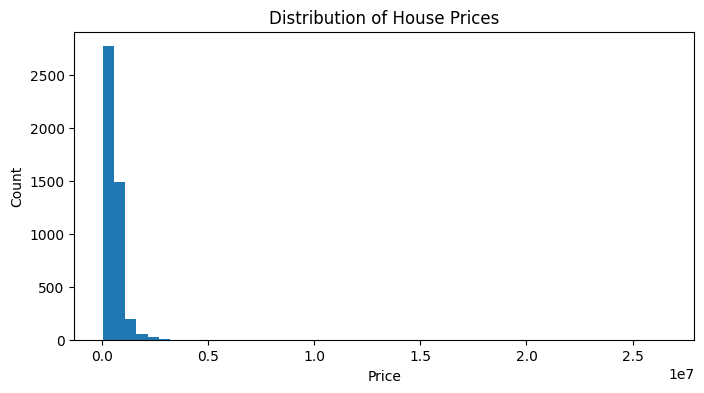

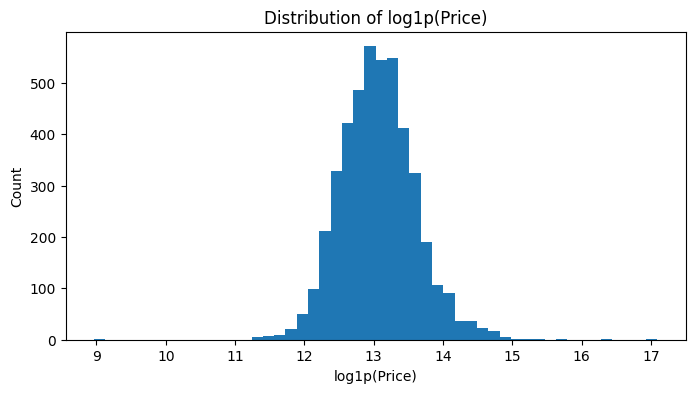

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df["price"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 4))
plt.hist(df["log_price"], bins=50)
plt.title("Distribution of log1p(Price)")
plt.xlabel("log1p(Price)")
plt.ylabel("Count")
plt.show()

The original price distribution is strongly right-skewed, with a long tail of high-priced properties. After applying `log1p(price)`, the distribution becomes more symmetric and suitable for linear modeling. Therefore, the linear models in this notebook are trained on the transformed target internally, while final predictions are converted back to the original price scale before computing MAPE.

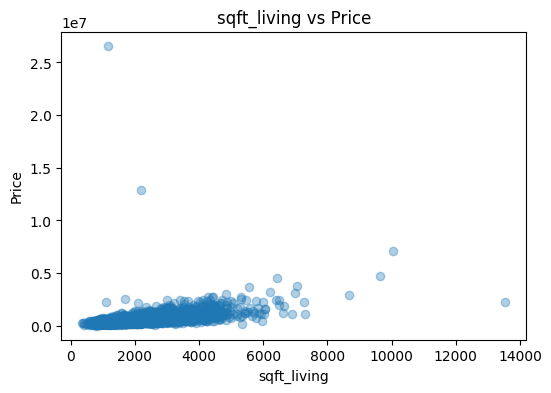

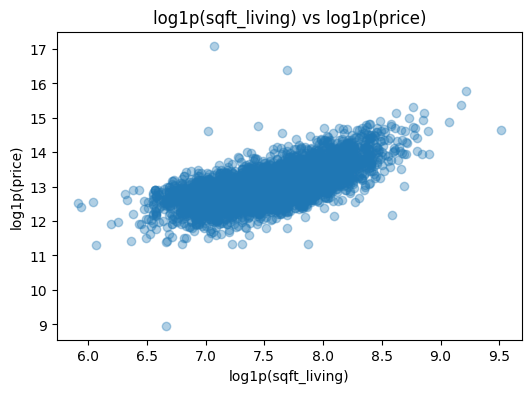

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(df["sqft_living"], df["price"], alpha=0.35)
plt.title("sqft_living vs Price")
plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(np.log1p(df["sqft_living"]), df["log_price"], alpha=0.35)
plt.title("log1p(sqft_living) vs log1p(price)")
plt.xlabel("log1p(sqft_living)")
plt.ylabel("log1p(price)")
plt.show()

Living area shows a strong positive relationship with house price. On the original scale, the relationship is clearly nonlinear and heteroskedastic, while the log-transformed relationship appears more linear. This supports the inclusion of log-transformed size features such as `log_sqft_living` and `log_sqft_lot`.

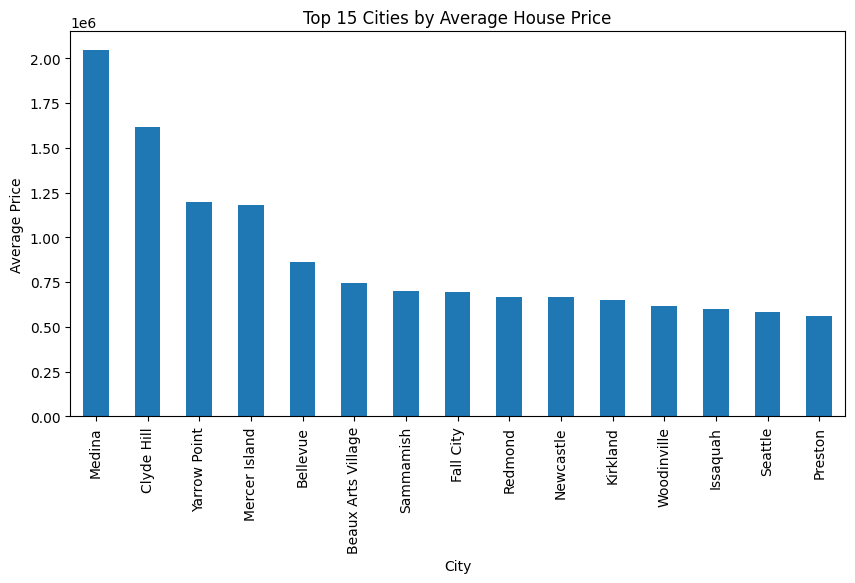

In [11]:
city_avg = (
    df.groupby("city")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
city_avg.plot(kind="bar")
plt.title("Top 15 Cities by Average House Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.show()

Average prices vary substantially across cities, indicating that location is an important determinant of house prices. This suggests that city-level categorical information should be included in the final model.

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

corr_with_log_price = (
    df[numeric_cols]
    .corr()["log_price"]
    .sort_values(ascending=False)
)

corr_with_log_price

log_price        1.000000
price            0.677507
sqft_living      0.671233
sqft_above       0.582076
bathrooms        0.548839
bedrooms         0.355801
view             0.323994
sqft_basement    0.312895
floors           0.305620
waterfront       0.141835
sqft_lot         0.085907
yr_built         0.059730
condition        0.058855
yr_renovated    -0.062878
Name: log_price, dtype: float64

The strongest numerical associations with `log_price` are expected to come from structural and quality-related variables such as living area, bathrooms, view, and waterfront status. These results help identify which raw variables should be prioritized and which engineered features are likely to be useful.

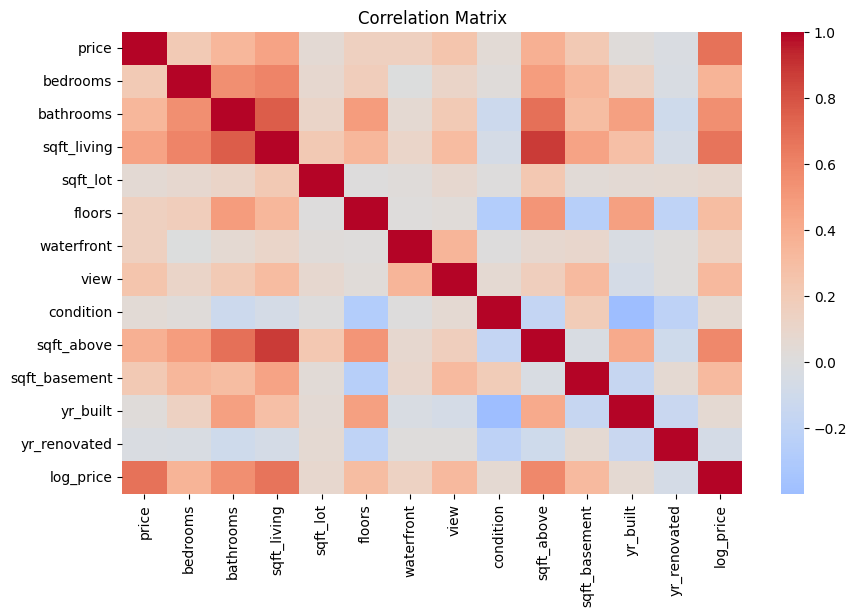

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix highlights strong relationships between structural features such as `sqft_living`, `sqft_above`, and `bathrooms`. These variables are highly correlated with each other, suggesting potential multicollinearity.

This motivates the use of regularized models such as Ridge and Lasso, which can stabilize coefficient estimates in the presence of correlated predictors.

In [14]:
corr_with_log_price.head(10)

log_price        1.000000
price            0.677507
sqft_living      0.671233
sqft_above       0.582076
bathrooms        0.548839
bedrooms         0.355801
view             0.323994
sqft_basement    0.312895
floors           0.305620
waterfront       0.141835
Name: log_price, dtype: float64

The strongest predictors of house price are primarily size-related variables such as `sqft_living` and `sqft_above`, followed by structural features like `bathrooms`. Quality-related variables such as `view` and `waterfront` also contribute, though with comparatively lower correlation strength. The strong relationships between size-related variables and price suggest that transformations (e.g., logarithmic scaling) and ratio-based features may improve model performance.

Additionally, the presence of multicollinearity motivates the use of regularization and careful feature selection in the modeling stage.

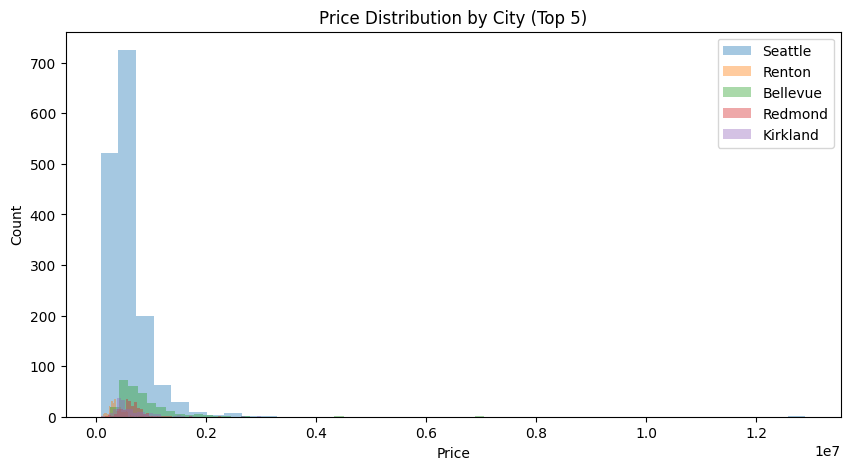

In [15]:
top_cities = df["city"].value_counts().head(5).index

plt.figure(figsize=(10, 5))

for city in top_cities:
    subset = df[df["city"] == city]
    plt.hist(subset["price"], bins=40, alpha=0.4, label=city)

plt.legend()
plt.title("Price Distribution by City (Top 5)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The distribution of house prices varies significantly across cities, not only in average price but also in spread and skewness. This indicates that location affects both the level and variability of prices.

This further supports the inclusion of location-based features in the model.

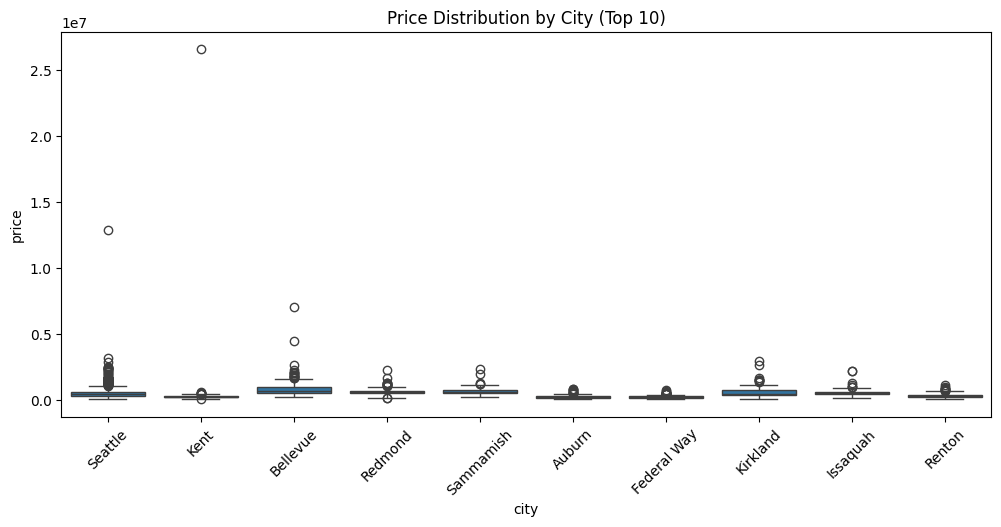

In [16]:
top_cities = df["city"].value_counts().head(10).index
subset = df[df["city"].isin(top_cities)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=subset, x="city", y="price")
plt.xticks(rotation=45)
plt.title("Price Distribution by City (Top 10)")
plt.show()

House prices vary significantly across cities, both in median level and dispersion. Some cities exhibit higher median prices and wider variability, indicating heterogeneous property markets.

This suggests that location is a key determinant of price and should be encoded appropriately in the model.

Several size-related variables such as `sqft_living`, `sqft_above`, and `bathrooms` are strongly correlated with each other. This indicates potential multicollinearity, which can destabilize ordinary least squares estimates.

Therefore, regularized models such as Ridge and Lasso are expected to perform better than standard linear regression.

## 4. Train-Test Split

The dataset is split into training and testing sets before feature engineering to prevent data leakage. All transformations and feature creation are based only on the training data.

In [54]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price", "log_price"])
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(3642, 15) (911, 15)


## 5. Feature Engineering

Based on the EDA, feature engineering focuses on:

- Log transformations for skewed size-related variables
- Ratio-based features to capture property efficiency
- Age-related features derived from construction year
- Simplifying correlated structural variables

These transformations aim to improve linear model performance while reducing noise and multicollinearity.

In [55]:
def feature_engineering(df):
    df = df.copy()

    # ---- LOG TRANSFORMATIONS ----
    df["log_sqft_living"] = np.log1p(df["sqft_living"])
    df["log_sqft_lot"] = np.log1p(df["sqft_lot"])

    # ---- RATIOS (USE LOG VERSION) ----
    df["bedroom_density"] = df["bedrooms"] / (df["log_sqft_living"] + 1)
    df["bathroom_density"] = df["bathrooms"] / (df["log_sqft_living"] + 1)

    # ---- AGE FEATURES ----
    sale_year = 2014
    df["house_age"] = sale_year - df["yr_built"]

    effective_year = df["yr_renovated"].fillna(df["yr_built"])
    df["years_since_renovation"] = sale_year - effective_year

    # ---- INTERACTION (USE LOG VERSION) ----
    df["living_x_view"] = df["log_sqft_living"] * df["view"]

    # ---- DROP ORIGINALS (VERY IMPORTANT) ----
    df = df.drop(columns=["sqft_living", "sqft_lot"])

    return df

In [56]:
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

Categorical variables such as `city` are encoded using one-hot encoding to allow their inclusion in linear models.

In [57]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

Feature scaling is applied to ensure that all variables contribute equally to regularized models such as Ridge and Lasso.

In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---- IMPUTE MISSING VALUES ----
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# ---- SCALE ----
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [60]:
X_train.head()
X_train.columns

Index(['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='object', length=203)

In [61]:
print("NaNs in train:", np.isnan(X_train_scaled).sum())
print("NaNs in test:", np.isnan(X_test_scaled).sum())

NaNs in train: 0
NaNs in test: 0


## 6. Linear Model Training and Evaluation

This section compares four linear models:
- Ordinary Least Squares (OLS)
- Ridge Regression
- Lasso Regression
- Elastic Net

The target variable is modeled on the `log1p(price)` scale, but predictions are converted back to the original price scale before computing Mean Absolute Percentage Error (MAPE), as required by the assignment.

In [62]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

In [63]:
models = {
    "OLS": LinearRegression(),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5),
    "Lasso": LassoCV(cv=5, max_iter=20000, random_state=42),
    "ElasticNet": ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        cv=5,
        max_iter=20000,
        random_state=42
    )
}

In [64]:
def evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test):
    model.fit(X_train_scaled, y_train)
    
    pred_log = model.predict(X_test_scaled)
    
    # convert back to original price space
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(pred_log)
    
    mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    return model, pred_log, y_test_actual, y_pred_actual, mape, mae, r2

In [65]:
results = []
fitted_models = {}
predictions_dict = {}

for name, model in models.items():
    fitted_model, pred_log, y_test_actual, y_pred_actual, mape, mae, r2 = evaluate_model(
        model, X_train_scaled, X_test_scaled, y_train, y_test
    )
    
    results.append({
        "Model": name,
        "MAPE": mape,
        "MAPE_percent": mape * 100,
        "MAE": mae,
        "R2": r2
    })
    
    fitted_models[name] = fitted_model
    predictions_dict[name] = {
        "pred_log": pred_log,
        "y_test_actual": y_test_actual,
        "y_pred_actual": y_pred_actual
    }

results_df = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
results_df

,Model,MAPE,MAPE_percent,MAE,R2
0,OLS,0.158482,15.848240,133589.712539,0.075562
1,Ridge,0.158766,15.876649,133537.993655,0.075536
2,Lasso,0.159377,15.937739,133687.277247,0.070436
3,ElasticNet,0.159377,15.937739,133687.277247,0.070436


The best linear model is selected based on test-set MAPE. Regularized models are expected to perform well because the engineered and one-hot encoded feature space contains correlated predictors and many location-specific indicators.

In [66]:
best_model_name = results_df.loc[0, "Model"]
print("Best linear model:", best_model_name)
print(results_df)

Best linear model: OLS
        Model      MAPE  MAPE_percent            MAE        R2
0         OLS  0.158482     15.848240  133589.712539  0.075562
1       Ridge  0.158766     15.876649  133537.993655  0.075536
2       Lasso  0.159377     15.937739  133687.277247  0.070436
3  ElasticNet  0.159377     15.937739  133687.277247  0.070436


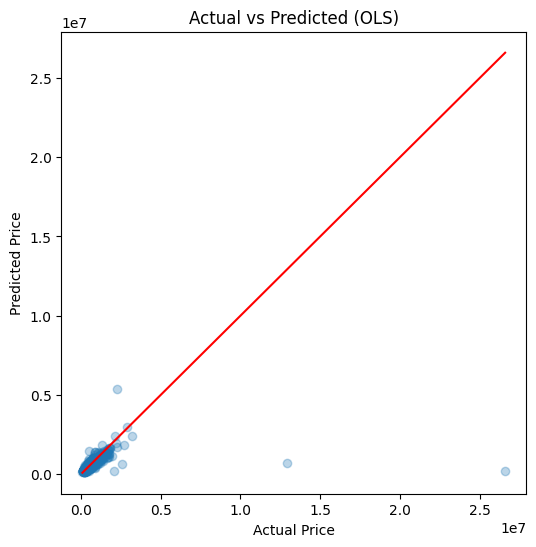

In [67]:
import matplotlib.pyplot as plt

best_preds = predictions_dict[best_model_name]

plt.figure(figsize=(6,6))
plt.scatter(best_preds["y_test_actual"], best_preds["y_pred_actual"], alpha=0.3)

plt.plot(
    [best_preds["y_test_actual"].min(), best_preds["y_test_actual"].max()],
    [best_preds["y_test_actual"].min(), best_preds["y_test_actual"].max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

The scatter plot shows that predictions generally follow the overall trend of actual prices, but with substantial dispersion. The model struggles to accurately predict extreme values, particularly high-priced properties, indicating limitations of linear modeling.

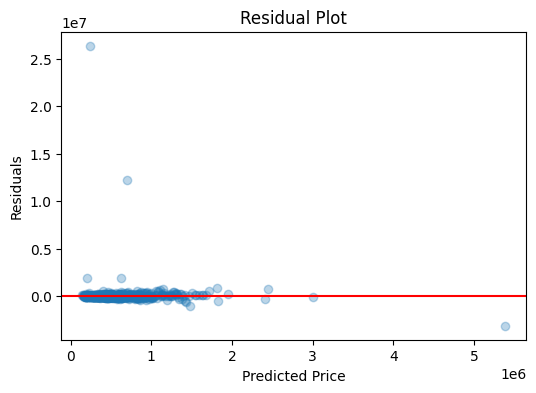

In [68]:
residuals = best_preds["y_test_actual"] - best_preds["y_pred_actual"]

plt.figure(figsize=(6,4))
plt.scatter(best_preds["y_pred_actual"], residuals, alpha=0.3)
plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows a non-random pattern, suggesting that the linear model does not fully capture the underlying relationships in the data. The presence of heteroskedasticity and systematic errors indicates that nonlinear effects may be important.

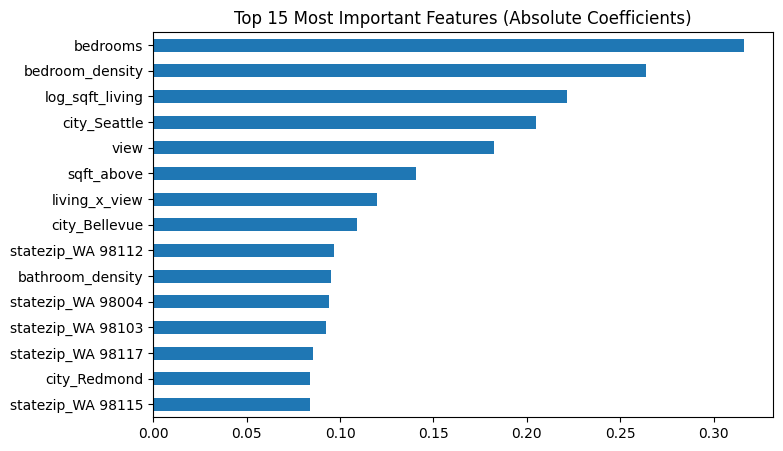

In [69]:
coef = pd.Series(fitted_models[best_model_name].coef_, index=X_train.columns)

top_coef = coef.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_coef.plot(kind="barh")
plt.title("Top 15 Most Important Features (Absolute Coefficients)")
plt.gca().invert_yaxis()
plt.show()

The most influential features are primarily related to property size and location indicators, consistent with the EDA findings. The importance of location-based dummy variables highlights the significant role of geographic factors in determining house prices.

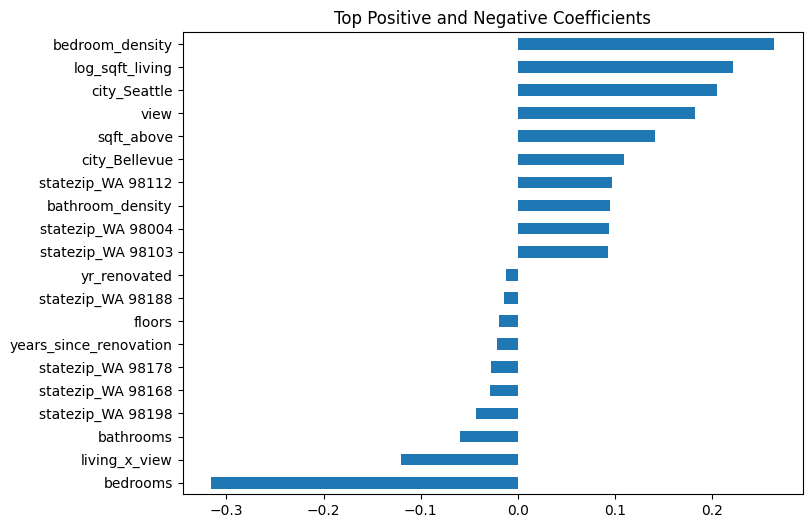

In [70]:
top_signed = pd.concat([
    coef.sort_values().head(10),
    coef.sort_values().tail(10)
])

plt.figure(figsize=(8,6))
top_signed.plot(kind="barh")
plt.title("Top Positive and Negative Coefficients")
plt.show()

Interestingly, the negative coefficient for bedrooms suggests that, holding total living area constant, properties with more bedrooms may have smaller individual room sizes, which could reduce perceived value.

## 7. XGBoost Benchmark

To evaluate whether nonlinear models can better capture complex relationships in the data, we implement XGBoost as a benchmark model. Unlike linear models, XGBoost can model interactions and nonlinear effects automatically.

In [75]:
from xgboost import XGBRegressor
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train (NO scaling)
xgb_model.fit(X_train, y_train)

# Predict
y_pred_log_xgb = xgb_model.predict(X_test)

# Convert back
y_pred_xgb = np.expm1(y_pred_log_xgb)
y_test_actual = np.expm1(y_test)

# Metrics
mape_xgb = mean_absolute_percentage_error(y_test_actual, y_pred_xgb)
mae_xgb = np.mean(np.abs(y_test_actual - y_pred_xgb))
r2_xgb = r2_score(y_test_actual, y_pred_xgb)

print("XGBoost Results:")
print("MAPE:", mape_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost Results:
MAPE: 0.1556863085331871
MAE: 131853.68199440403
R2: 0.08020512339779862


In [76]:
xgb_result = pd.DataFrame([{
    "Model": "XGBoost",
    "MAPE": mape_xgb,
    "MAPE_percent": mape_xgb * 100,
    "MAE": mae_xgb,
    "R2": r2_xgb
}])

final_results = pd.concat([results_df, xgb_result], ignore_index=True)
final_results = final_results.sort_values("MAPE").reset_index(drop=True)

final_results

,Model,MAPE,MAPE_percent,MAE,R2
0,XGBoost,0.155686,15.568631,131853.681994,0.080205
1,OLS,0.158482,15.848240,133589.712539,0.075562
2,Ridge,0.158766,15.876649,133537.993655,0.075536
3,Lasso,0.159377,15.937739,133687.277247,0.070436
4,ElasticNet,0.159377,15.937739,133687.277247,0.070436


The final comparison shows that XGBoost achieved the lowest test-set MAPE (15.57%), slightly outperforming OLS (15.85%). The performance gap is small, indicating that careful feature engineering allows linear models to remain competitive even against a more flexible nonlinear benchmark.

This is an important result from a stakeholder perspective: if interpretability and transparency are priorities, the small reduction in error from XGBoost may not justify the loss of model simplicity.

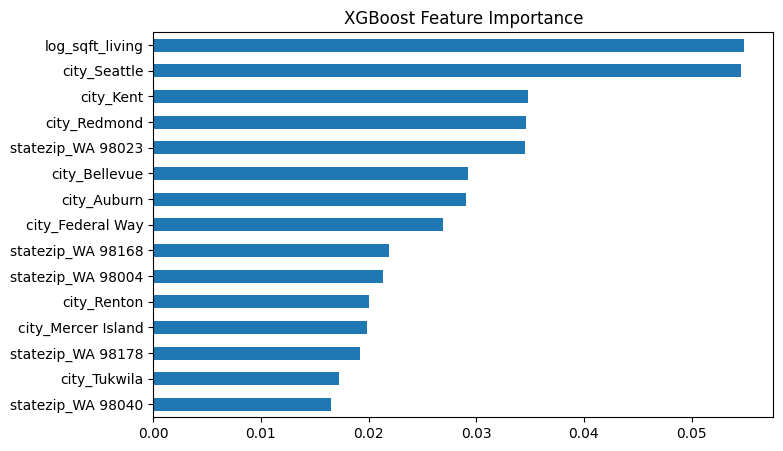

In [77]:
import pandas as pd

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
xgb_importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## 8. Conclusion

This project developed and evaluated interpretable linear models for house price prediction using feature engineering, regularization, and careful validation.

Among the linear approaches, OLS achieved the best performance with a test-set MAPE of 15.85%, while Ridge, Lasso, and Elastic Net performed slightly worse. This suggests that regularization was not necessary to improve predictive accuracy in this dataset, despite the presence of correlated predictors.

XGBoost achieved the overall best result with a MAPE of 15.57%, but only by a small margin. This indicates that the engineered linear model already captured much of the available predictive signal. From a practical perspective, this is an important finding: linear models remain competitive while offering much greater interpretability and transparency.

Overall, the results show that property size and location are the dominant drivers of house prices, and that thoughtful feature engineering can make linear models surprisingly effective even when compared with more flexible nonlinear methods.